# Moving Average (MA) Processes

At each time step a fresh random **shock** arrives -- think of it as the news of the day.
In a moving-average process, the value now is that shock plus a fading echo of the shocks
just before it:

$$X[n] = \text{mean} + \varepsilon[n] + \theta_1\,\varepsilon[n-1] + \dots + \theta_q\,\varepsilon[n-q]$$

The echo lasts exactly $q$ steps and then **stops dead**, so two values more than $q$ apart
share no shocks at all and are completely uncorrelated. That sharp cutoff is the signature
of a moving-average process.

Despite the name, this is **not** the everyday "average of the last few values": it averages
the recent *shocks*, not the recent values, and it never looks at its own past.

In [1]:
from symbulate import *

## Create a process and draw a path

`coefs` holds one weight per past shock, so its length is the order $q$. Here is an MA(2):
the value now carries 0.8 of the previous shock and 0.5 of the one before that.

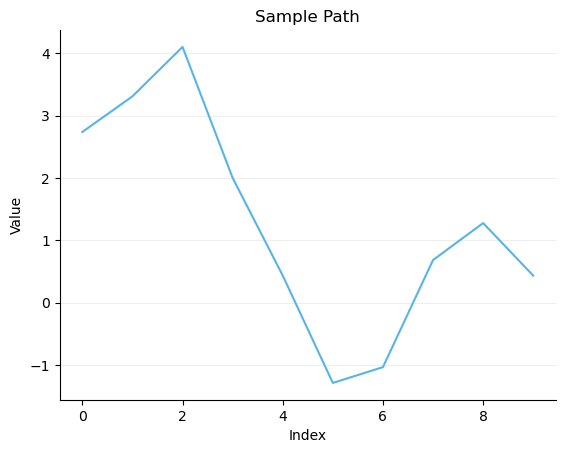

In [2]:
X = MA(coefs=[0.8, 0.5])
X.draw().plot()

## Simulate and plot sample paths

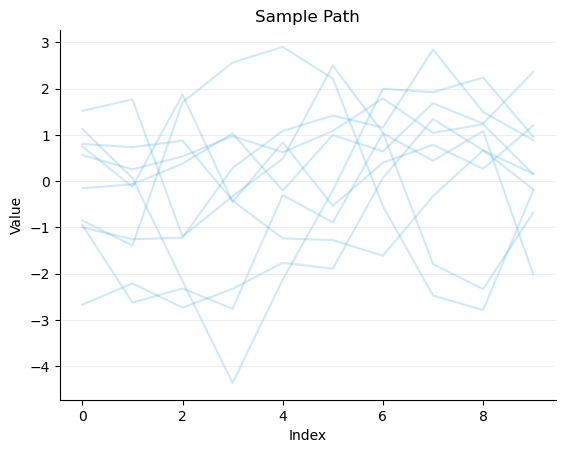

In [3]:
X.sim(10).plot()

## The value at a fixed time

`X[n]` is the random variable "the value at time $n$", so it can be simulated and
summarised like any other.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


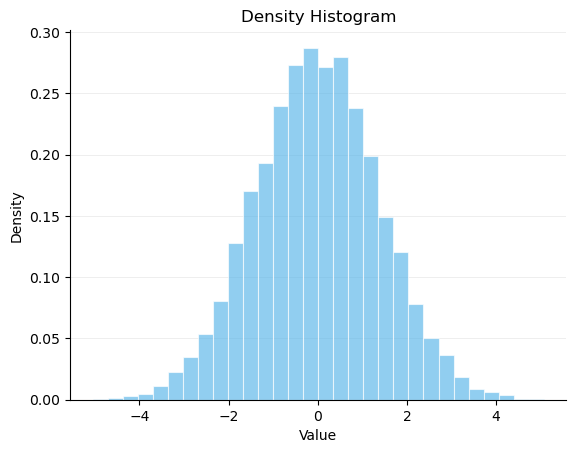

In [4]:
X[10].sim(10000).plot()

Its mean is 0 and its variance is $1 + 0.8^2 + 0.5^2 = 1.89$.

In [5]:
values = X[10].sim(10000)
values.mean(), values.var()

(-0.0026454798170589635, 1.841298426767609)

## The cutoff: correlation vanishes past lag $q$

This is the whole point of a moving-average process. Values 1 or 2 steps apart share
shocks, so they are correlated; values 3 or more apart share none, so they are not.

`X[0] & X[k]` is the pair of values at those two times, and simulating the pair gives
their correlation directly.

In [6]:
for lag in [1, 2, 3, 4]:
    print("lag", lag, " correlation", round((X[0] & X[lag]).sim(10000).corr(), 3))

lag 1  correlation 0.638


lag 2  correlation 0.261


lag 3  correlation -0.001


lag 4  correlation 0.007


Lags 1 and 2 show real correlation; lag 3 onward is essentially zero. An autoregressive
process, by contrast, would show correlation that fades gradually and never quite reaches
zero.

## Longer and shorter memory

More coefficients means a longer echo, which makes the path visibly smoother -- neighbouring
values now share several shocks. With no coefficients at all there is no echo, and the
process is just independent noise.

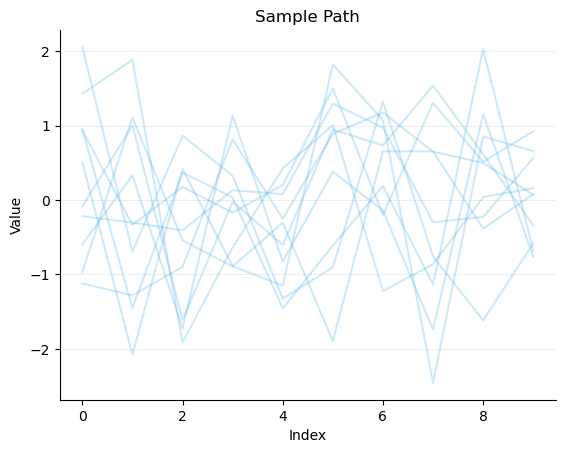

In [7]:
MA(coefs=[]).sim(10).plot()

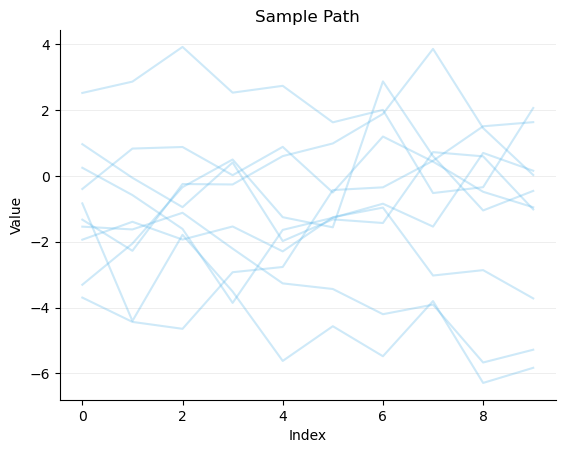

In [8]:
MA(coefs=[0.9, 0.9, 0.9, 0.9, 0.9]).sim(10).plot()

## Choosing the shocks and the level

The shocks are `Normal(0, 1)` by default, but any distribution works, and `mean` sets the
level the process varies around.

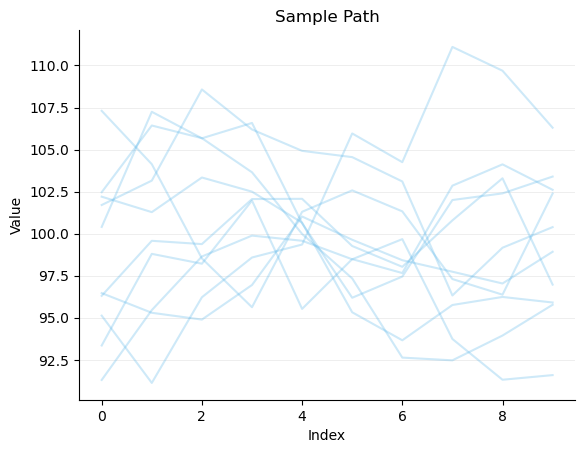

In [9]:
Y = MA(coefs=[0.8, 0.5], noise_dist=Normal(0, 3), mean=100)
Y.sim(10).plot()

In [10]:
Y[20].sim(10000).mean()

Simulating... [████████████████████████████░░] 9423/10000 (94%)

Simulating... [████████████████████████████░░] 9500/10000 (95%)

Simulating... [████████████████████████████░░] 9600/10000 (96%)

Simulating... [█████████████████████████████░] 9700/10000 (97%)

Simulating... [█████████████████████████████░] 9800/10000 (98%)

Simulating... [█████████████████████████████░] 9900/10000 (99%)

Simulating... [██████████████████████████████] 10000/10000 (100%)

Simulating... [██████████████████████████████] 10000/10000 (100%)

100.0243020429179

## Every value has the same distribution

An MA process is defined over *all* time, with no beginning, which is what makes every one
of its values have the same distribution. Simulating it has to start somewhere, though, and
`X[0]` needs the $q$ shocks from *before* time 0. Symbulate simulates those too, so the
process is already running when you read the first value. Had they been left out, `X[0]`
would have had no echoes and `X[1]` only one, making the first few values artificially
small -- and any variance or correlation measured from the start of a path would come out
wrong. Drawing $q$ extra shocks costs almost nothing and makes the simulation match the
definition exactly, so there is no setting to configure.

The variance is the same at the very first value as it is much later:

In [11]:
for n in [0, 1, 2, 10, 50]:
    print("n =", n, " variance", round(X[n].sim(10000).var(), 2))

n = 0  variance 1.89


n = 1  variance 1.89


n = 2  variance 1.89


n = 10  variance 1.85


Simulating... [████████████░░░░░░░░░░░░░░░░░░] 4065/10000 (40%)

...

Simulating... [█████████████████████████████░] 9800/10000 (98%)

Simulating... [█████████████████████████████░] 9900/10000 (99%)

Simulating... [██████████████████████████████] 10000/10000 (100%)

Simulating... [██████████████████████████████] 10000/10000 (100%)

n = 50  variance 1.92
